In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"
import keras

In [ ]:
# fasion MNIST 데이터 다운로드
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

In [ ]:
model = keras.models.Sequential([keras.layers.Rescaling(1/255),
                                 keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
                                 keras.layers.MaxPooling2D((2, 2)),
                                 keras.layers.Flatten(),
                                 keras.layers.Dense(10)])

### 강아지 - 고양이 분류

In [5]:
# 이미지 전처리
from torchvision import transforms
IMAGE_SIZE = 224
transform = transforms.Compose([transforms.Resize((256, 256)), # 이미지마다 크기가 다르므로 통일
                                transforms.CenterCrop((IMAGE_SIZE, IMAGE_SIZE)), # 가운데만 잘라냄
                                transforms.ToTensor(),
                                transforms.Lambda(lambda x: (x / 127.5) - 1)]) # 0 ~ 255의 픽셀 값을 -1 ~ 1 사이로 변환

In [3]:
# 데이터셋 가져오기
from torchvision.datasets import ImageFolder
train_dataset = ImageFolder(root='../data/cats_and_dogs_filtered/train', transform=transform)
val_dataset = ImageFolder(root='../data/cats_and_dogs_filtered/validation', transform=transform)

from torch.utils.data import DataLoader
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [4]:
# 모델 정의
# Keras는 기본적으로 Height, Width, Channels 순으로 입력
# PyTorch는 Channels가 먼저 나오므로 데이터 포맷을 맞춰야 함
model = keras.Sequential([keras.Input(shape=(3, IMAGE_SIZE, IMAGE_SIZE)), # (Channels, Height, Width)
                          keras.layers.Conv2D(32, (3, 3), activation='relu', data_format='channels_first'),
                          keras.layers.MaxPooling2D((2, 2), data_format='channels_first'), # Channel이 가장 앞에 있음을 알림
                          keras.layers.Flatten(),
                          keras.layers.Dense(512, activation='relu'),
                          keras.layers.Dense(1, activation='sigmoid')])

In [5]:
# 학습
model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.001),
              loss='binary_crossentropy', metrics=['accuracy'])

model.fit(train_loader, epochs=1, validation_data=val_loader)

63/63 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.4900 - loss: 0.7275 - val_accuracy: 0.5000 - val_loss: 0.6934


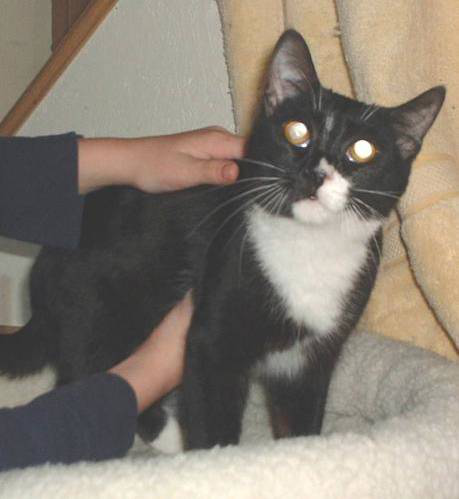

In [7]:
# 예측 결과
# 이미지 한 장 가져오기
from PIL import Image
image = Image.open('../data/cats_and_dogs_filtered/validation/cats/cat.2000.jpg')
image # 이미지 보기

In [8]:
# 변환
x = transform(image)
x.shape # 채널, 높이, 폭

torch.Size([3, 224, 224])

In [ ]:
# 모델에 입력
batch = x.unsqueeze(0) # 차원을 추가 (expand_dims와 같음), [1, 3, 224, 224]
model.predict(batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


array([[0.51193166]], dtype=float32)

### Data Augmentation(데이터 증강)
- 기존 데이터를 변형하여 데이터 양을 늘리는 기법(회전, 좌우 반전, 색상 변경 등)

In [2]:
# 예시 이미지 불러오기
from PIL import Image
img = Image.open('../data/pump_horse.jpg')

In [3]:
# 여러 이미지 보기
def concat_images(images):
    n = len(images)
    width, height = 128, 128
    total_width = n * width
    new_im = Image.new('RGB', (total_width, height), color='white')
    for i, im in enumerate(images):
        new_im.paste(im.resize((width, height)), (width * i, 0))
    return new_im

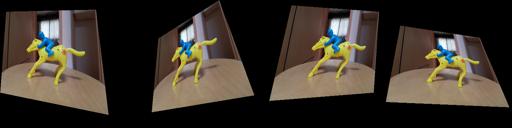

In [6]:
# RandomPerspective
# 무작위로 perspective를 바꿈
transform = transforms.RandomPerspective(distortion_scale=0.6, p=1.0)
concat_images([transform(img) for _ in range(4)])

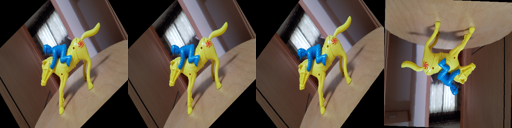

In [7]:
# RandomRotation
# 무작위로 회전
transform = transforms.RandomRotation(degrees=(0, 180))
concat_images([transform(img) for _ in range(4)])

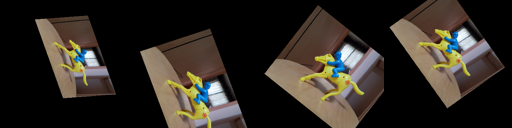

In [8]:
# RandomAffine
# 무작위 아핀 변환
transform = transforms.RandomAffine(
    degrees=(30, 70), translate=(0.1, 0.3), scale=(0.5, 0.75), shear=(10, 30)) # 회전, 평행이동, 확대/축소, 기울이기 범위
concat_images([transform(img) for _ in range(4)])

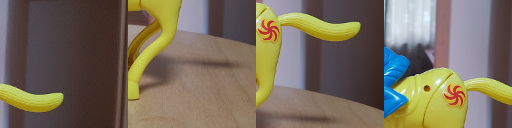

In [ ]:
# RandomCrop
# 무작위로 주어진 크기의 일부 영역을 잘라냄
transform = transforms.RandomCrop(size=(128, 128))
concat_images([transform(img) for _ in range(4)]) # 너무 작게 잘라서 객체가 안 보이면 학습에 방해

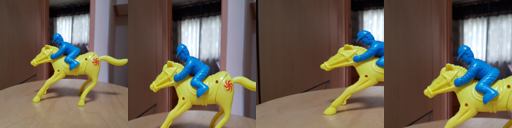

In [10]:
# RandomResizedCrop
# 무작위로 잘라낸 후, 정해진 크기로 변경
transform = transforms.RandomResizedCrop(size=(512, 512))
concat_images([transform(img) for _ in range(4)])

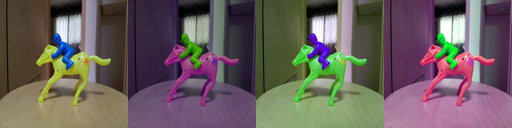

In [11]:
# ColorJitter
# 무작위로 색을 변경
# brightness(밝기), contrast(대조), 채도(saturation), hue(색상)
transform = transforms.ColorJitter(brightness=.5, hue=.3)
concat_images([transform(img) for _ in range(4)])

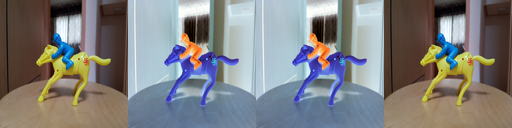

In [12]:
# RandomInvert
# 무작위로 색 반전
transform = transforms.RandomInvert()
concat_images([transform(img) for _ in range(4)])

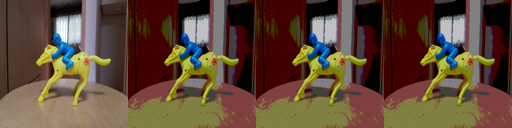

In [13]:
# RandomPosterize
# 무작위로 포스터화(색의 비트 수를 낮춤)
transform = transforms.RandomPosterize(bits=2)
concat_images([transform(img) for _ in range(4)])

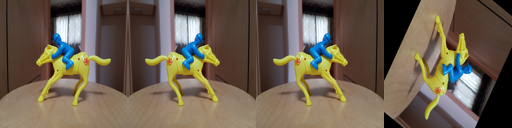

In [14]:
# RandomChoice
# 무작위로 고르기
transform = transforms.RandomChoice([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
])
concat_images([transform(img) for _ in range(4)])

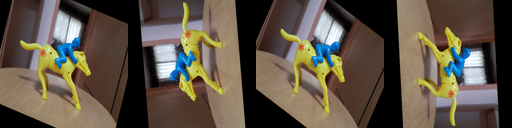

In [18]:
# RandomApply
# 각각의 변환을 확률 p에 따라 무작위로 적용
transform = transforms.RandomApply([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
], p=0.9)
concat_images([transform(img) for _ in range(4)])

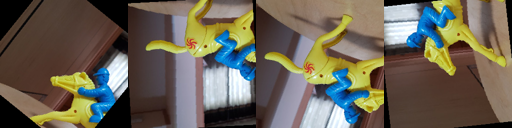

In [19]:
# RandomOrder
# 무작위 순서로 적용
transform = transforms.RandomOrder([
    transforms.RandomRotation(180),
    transforms.RandomCrop((256, 256)),
])
concat_images([transform(img) for _ in range(4)])

In [ ]:
# 이미지 증강을 위한 transform 예시
transform = transforms.Compose([transforms.RandomChoice([transforms.RandomHorizontalFlip(),
                                                         transforms.RandomVerticalFlip()]),
                                transforms.Resize((256, 256)),  # 이미지마다 크기가 다르므로 통일
                                transforms.CenterCrop((IMAGE_SIZE, IMAGE_SIZE)),  # 가운데만 잘라냄
                                transforms.ToTensor(),
                                transforms.Lambda(lambda x: (x / 127.5) - 1)])